# Classifying data using Support Vector Machines(SVMs) in Python
What is Support Vector Machine (SVM)?

SVM is a supervised learning algorithm used for classification and regression. It finds an optimal decision boundary (hyperplane) that separates different classes in a dataset.

Linear SVM: Works well when data is linearly separable.

Non-linear SVM: Uses kernels like RBF (Radial Basis Function) to handle complex boundaries.

Given a set of training examples, each marked as belonging to one or the other of two categories, an SVM training algorithm builds a model that assigns new examples to one category or the other, making it a non-probabilistic binary linear classifier. 

In [21]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [22]:
# Load Iris dataset
iris = datasets.load_iris()

# Convert to DataFrame for better readability
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target  # Adding target labels

# Display first 5 rows
print(df.head())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [23]:
# Check dataset information
print(df.info())

# Check class distribution
print("\nClass distribution:\n",df['target'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB
None

Class distribution:
 target
0    50
1    50
2    50
Name: count, dtype: int64


C:\Users\franc\AppData\Local\Temp\ipykernel_2152\1835336682.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['target'], palette='viridis')


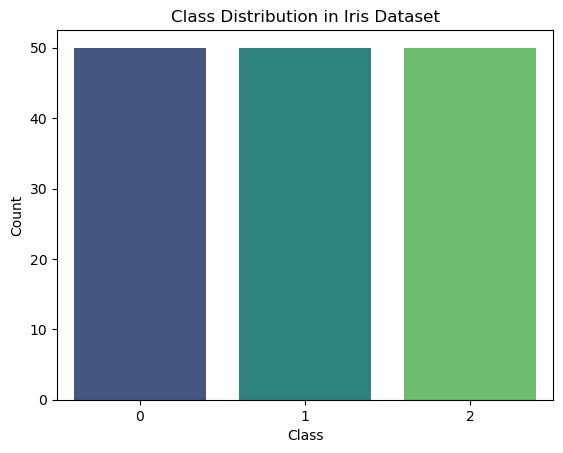

In [24]:
sns.countplot(x=df['target'], palette='viridis')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution in Iris Dataset')
plt.show()


In [25]:
# Split Data into Training and Testing Sets
X = df.drop(columns=['target'])  # Features
y = df['target']  # Labels

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [26]:
# Standardize Features (Important for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [30]:
# Train an SVM Model
# Create SVM model with RBF kernel
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')

# Train the model
svm_model.fit(X_train, y_train)



SVC()

In [31]:
#  Make Predictions

# Predict on test data
y_pred = svm_model.predict(X_test)


Accuracy: 0.97

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



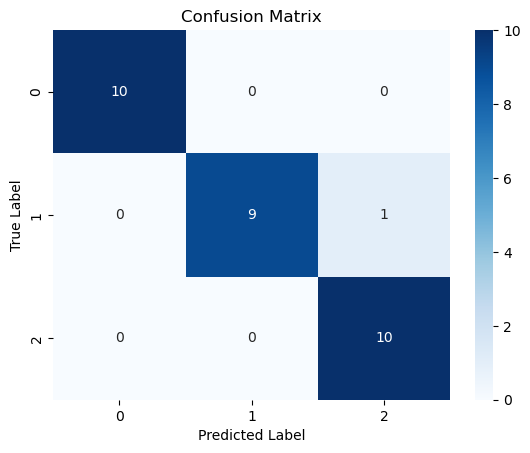

In [32]:
# Evaluate the Model
# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Show confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()



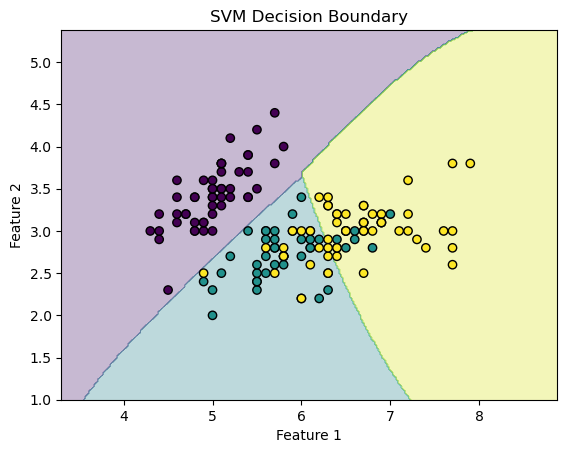

In [33]:
# Use only first two features for visualization
X_vis = df.iloc[:, [0, 1]].values  # First two columns
y_vis = df['target'].values  # Labels

# Train SVM on reduced data
"""
Kernel: 'rbf' ,for handling non-linearly separable data.
C = 1.0 (Regularization parameter to balance margin maximization and misclassification).
gamma = 'scale' (Default value for controlling influence of each training example).
"""
svm_vis = SVC(kernel='rbf', C=1.0, gamma='scale').fit(X_vis, y_vis)

# Function to plot decision boundary
def plot_decision_boundary(X, y, model):
    h = 0.02  # Step size (determines grid resolution)

    # Define min and max for both axes, with some padding
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Create a grid of points in feature space
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict class labels for each point in the grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])  # Flatten and predict
    Z = Z.reshape(xx.shape)  # Reshape to match the grid

    # Plot the decision boundary
    plt.contourf(xx, yy, Z, alpha=0.3)

    # Plot original data points
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k')

    # Labels and title
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('SVM Decision Boundary')
    plt.show()


plot_decision_boundary(X_vis, y_vis, svm_vis)


# Trying Different Kernels (Linear, Polynomial, Sigmoid)

Linear Kernel → Best for linearly separable data.

Polynomial Kernel → Suitable when the relationship is non-linear but still smooth.

Sigmoid Kernel → Similar to neural networks; useful for specific cases.


In [34]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Try different kernels
kernels = ['linear', 'poly']
models = {}

for kernel in kernels:
    print(f"\nTraining SVM with {kernel} kernel...")
    
    # Train SVM with the selected kernel
    model = SVC(kernel=kernel, C=1.0, gamma='scale')
    model.fit(X_train, y_train)
    
    # Store model for later comparison
    models[kernel] = model
    
    # Evaluate performance
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"Accuracy with {kernel} kernel: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))


Training SVM with linear kernel...
Accuracy with linear kernel: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Training SVM with poly kernel...
Accuracy with poly kernel: 0.9667
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



# Hyperparameter Tuning (C, Gamma) using GridSearchCV
Hyperparameter tuning helps optimize SVM for better performance.

Steps in Hyperparameter Tuning:

C: Controls trade-off between maximizing margin and misclassification.

Gamma: Controls influence of training samples (only for rbf, poly, sigmoid).

Implementation using GridSearchCV

In [35]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameters to test
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']
}


# Perform grid search
grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Print best parameters and best accuracy
print("\nBest Hyperparameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

# Train final model with best parameters
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 80 candidates, totalling 400 fits

Best Hyperparameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best Accuracy: 0.9833333333333334


# Using Real-World Datasets (Spam Detection, Image Classification)
## Spam Detection (Text Classification using SVM)
We'll classify SMS messages as Spam or Ham (Not Spam) using the SMS Spam Collection Dataset.

Steps:

Load dataset (Spam vs. Ham messages).

Preprocess text (remove stopwords, tokenize).

Convert text to numerical representation (TF-IDF).

Train an SVM classifier.

In [36]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# Load dataset (download from: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset)
df = pd.read_csv("C:\\Users\\franc\\Datascience_python\\dataset\\spam.csv", encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'text']  # Rename columns
df['label'] = df['label'].map({'ham': 0, 'spam': 1})  # Convert labels to binary

# Display first few rows
print(df.head())

# Count the number of spam vs. ham messages
print('\n',df["label"].value_counts())

   label                                               text
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...

 label
0    4825
1     747
Name: count, dtype: int64


In [37]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2, random_state=42, stratify=df['label'])

In [38]:
# Create an SVM pipeline with TF-IDF
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000)),
    ('svm', SVC(kernel='linear', C=1.0))
])

Spam Detection Accuracy: 98.11659192825111 %

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.98      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



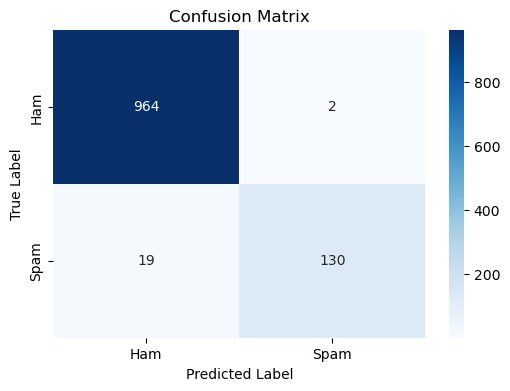

In [44]:
# Train model
pipeline.fit(X_train, y_train)

# Evaluate
y_pred = pipeline.predict(X_test)
print("Spam Detection Accuracy:", accuracy_score(y_test, y_pred)*100,"%")
# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()



MNIST Accuracy: 0.8583333333333333
              precision    recall  f1-score   support

           0       1.00      0.75      0.86        36
           1       1.00      0.81      0.89        36
           2       1.00      0.86      0.92        35
           3       1.00      0.89      0.94        37
           4       1.00      0.89      0.94        36
           5       1.00      1.00      1.00        37
           6       1.00      0.81      0.89        36
           7       1.00      0.72      0.84        36
           8       0.41      1.00      0.58        35
           9       1.00      0.86      0.93        36

    accuracy                           0.86       360
   macro avg       0.94      0.86      0.88       360
weighted avg       0.94      0.86      0.88       360



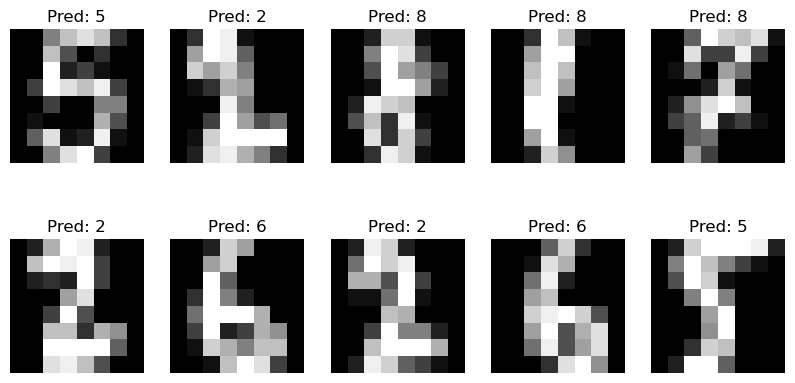

In [49]:
# Image Classification using SVM

from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

# Load dataset
digits = load_digits()
X, y = digits.data, digits.target  # Features and labels

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train SVM
svm_model = SVC(kernel='rbf', C=10, gamma=0.01)
svm_model.fit(X_train, y_train)

# Predict
y_pred = svm_model.predict(X_test)

# Evaluate
print("MNIST Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Plot some images with predictions
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(8, 8), cmap='gray')
    ax.set_title(f'Pred: {y_pred[i]}')
    ax.axis('off')
plt.show()
